# Pure ViT-Fuzzy Binary Classification Model (Pneumonia Chest X-Ray)
# Architecture: X-Ray → CLAHE → Linear Patch Embed → ViT Blocks → Neural Projection → Fuzzy Membership → Cosine Classifier
# Framework: Pure CuPy (GPU Accelerated) | Hardware Target: RTX 3050 4GB

# 1. Initialization and GPU Memory Management

In [1]:
import os
import glob
import cv2
import math
import gc
import threading
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Enforce reproducibility
SEED = 42
np.random.seed(SEED)
cp.random.seed(SEED)

# Configure GPU and memory limits for 4GB VRAM
print(f"Using GPU device ID: {cp.cuda.Device(0).id}")
cp.cuda.Device(0).use()

free_mem, total_mem = cp.cuda.Device(0).mem_info
safety_buffer = 500 * 1024**2 
max_safe_limit = free_mem - safety_buffer

if max_safe_limit > 0:
    cp.get_default_memory_pool().set_limit(size=max_safe_limit)

def force_free_vram():
    """Aggressively clear memory to prevent Out-Of-Memory errors."""
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()

force_free_vram()

c:\Users\Computec\.conda\envs\nlp_gpu\lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


Using GPU device ID: 0


# 2. Advanced Configuration & Hyperparameters

In [ ]:
CONFIG = {
    # --- Data & Dimensions ---
    'img_size': 128,            
    'channels': 3,              
    'patch_size': 8,            # Added patch size for pure ViT embedding
    
    # --- ViT Architecture ---
    'embed_dim': 64,            
    'num_heads': 8,             
    'num_layers': 4,            
    
    # --- Fuzzy Logic Backend ---
    'proj_dim': 32,             
    'num_rules': 16,            
    'temperature': 0.5,         
    
    # --- Training Dynamics ---
    'batch_size': 32,            
    'accumulation_steps': 8,    
    'epochs': 20,               
    'learning_rate': 3e-4,      
    'weight_decay': 0.001,      
    'clip_val': 1.0,            
    
    # --- Paths ---
    'dataset_path': r'C:\Users\Computec\Desktop\nee_sc_pro\Pneumonia_Dataset',
    
    # --- Dynamic Variables (Populated Later) ---
    'num_classes': None,        
    'class_weights': None       
}

# Calculate exact number of patches (128 // 8 = 16) -> 16x16 grid = 256 patches
CONFIG['num_patches'] = (CONFIG['img_size'] // CONFIG['patch_size']) ** 2 

# 3. Pneumonia Loading, CLAHE Preprocessing & Async Prefetching

In [ ]:
def load_pneumonia_dataset(data_dir, img_size):
    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"CRITICAL ERROR: Could not find '{data_dir}'.")

    X, y = [], []
    class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    
    if len(class_names) == 0:
        raise ValueError(f"No class folders found inside {data_dir}.")

    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    print(f"Loading X-Rays from {len(class_names)} classes ({class_names}) with Grayscale CLAHE...")
    
    for class_idx, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)
        image_paths = glob.glob(os.path.join(class_path, '*.*'))
        
        for img_file in image_paths:
            img = cv2.imread(img_file, cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            
            img = cv2.resize(img, (img_size, img_size))
            img = clahe.apply(img)
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            
            X.append(img / 255.0)
            y.append(class_idx)

    X_np = np.array(X, dtype=np.float32).transpose(0, 3, 1, 2)
    y_np = np.array(y, dtype=np.int32)
    return X_np, y_np, class_names

X_data, y_data, classes = load_pneumonia_dataset(CONFIG['dataset_path'], CONFIG['img_size'])
CONFIG['num_classes'] = len(classes)

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.10, random_state=42, stratify=y_data
)

class_counts = np.bincount(y_train, minlength=len(classes))
class_counts = np.maximum(class_counts, 1)  
total_train_samples = len(y_train)

class_weights = total_train_samples / (len(classes) * class_counts)
CONFIG['class_weights'] = np.clip(class_weights, 0.1, 5.0).astype(np.float32)

print("-" * 40)
print(f"Total Real Images Loaded: {len(X_data)}")
print(f"Train samples (90%): {len(X_train)} | Test samples (10%): {len(X_test)}")
print("-" * 40)

class DataPrefetcher:
    def __init__(self, X, y, batch_size, augment=False):
        import queue
        self.X, self.y = X, y
        self.batch_size = batch_size
        self.augment = augment
        self.queue = queue.Queue(maxsize=1)
        self.indices = np.random.permutation(len(X))
        self.pos = 0
        self._preload()

    def _preload(self):
        def _worker():
            if self.pos >= len(self.indices):
                self.queue.put(None)
                return
            idx = self.indices[self.pos : self.pos + self.batch_size]
            X_np = self.X[idx].copy()
            y_np = self.y[idx]
            
            if self.augment:
                flips = np.random.rand(len(X_np)) > 0.5
                if np.any(flips):
                    X_np[flips] = X_np[flips, :, :, ::-1]
                brightness = np.random.uniform(-0.1, 0.1, (len(X_np), 1, 1, 1)).astype(np.float32)
                X_np = np.clip(X_np + brightness, 0.0, 1.0)
                
            X_gpu = cp.asarray(X_np, dtype=cp.float32)
            y_gpu = cp.asarray(y_np, dtype=cp.int32)
            self.queue.put((X_gpu, y_gpu))
            
        threading.Thread(target=_worker, daemon=True).start()

    def next(self):
        batch = self.queue.get() 
        if batch is not None:
            self.pos += self.batch_size
            self._preload()
        return batch

    def reset(self):
        import queue
        while not self.queue.empty():
            try: self.queue.get_nowait()
            except queue.Empty: break
        self.indices = np.random.permutation(len(self.X))
        self.pos = 0
        self._preload()

Loading X-Rays from 2 classes (['NORMAL', 'PNEUMONIA']) with Grayscale CLAHE...
----------------------------------------
Total Real Images Loaded: 11236
Train samples (90%): 10112 | Test samples (10%): 1124
----------------------------------------


# 4. Math Primitives

In [ ]:
class AdamWOptimizer:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.01, clip_val=1.0):
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.weight_decay, self.clip_val = weight_decay, clip_val
        self.t = 0
        
    def update(self, param, grad, m, v):
        self.t += 1
        grad = cp.clip(grad, -self.clip_val, self.clip_val)
        param -= self.lr * self.weight_decay * param
        m = self.beta1 * m + (1 - self.beta1) * grad
        v = self.beta2 * v + (1 - self.beta2) * (grad ** 2)
        m_hat = m / (1 - self.beta1 ** self.t)
        v_hat = v / (1 - self.beta2 ** self.t)
        param -= self.lr * m_hat / (cp.sqrt(v_hat) + self.eps)
        return param, m, v

class Linear:
    def __init__(self, in_dim, out_dim):
        self.W = cp.random.randn(in_dim, out_dim, dtype=cp.float32) * cp.sqrt(2.0 / in_dim)
        self.b = cp.zeros(out_dim, dtype=cp.float32)
        self.dW, self.db = cp.zeros_like(self.W), cp.zeros_like(self.b)
        self.m_W, self.v_W = cp.zeros_like(self.W), cp.zeros_like(self.W)
        self.m_b, self.v_b = cp.zeros_like(self.b), cp.zeros_like(self.b)

    def forward(self, x):
        self.x = x
        if x.ndim == 3:
            B, S, F = x.shape
            return (cp.dot(x.reshape(-1, F), self.W) + self.b).reshape(B, S, -1)
        return cp.dot(x, self.W) + self.b

    def backward(self, grad_out, optimizer, update=False):
        if self.x.ndim == 3:
            B, S, F = self.x.shape
            g_flat = grad_out.reshape(-1, grad_out.shape[-1])
            x_flat = self.x.reshape(-1, F)
            self.dW += cp.dot(x_flat.T, g_flat)
            self.db += cp.sum(g_flat, axis=0)
            grad_in = cp.dot(g_flat, self.W.T).reshape(B, S, -1)
        else:
            self.dW += cp.dot(self.x.T, grad_out)
            self.db += cp.sum(grad_out, axis=0)
            grad_in = cp.dot(grad_out, self.W.T)
            
        if update:
            self.W, self.m_W, self.v_W = optimizer.update(self.W, self.dW, self.m_W, self.v_W)
            self.b, self.m_b, self.v_b = optimizer.update(self.b, self.db, self.m_b, self.v_b)
            self.dW.fill(0); self.db.fill(0)
        return grad_in

class ReLU:
    def forward(self, x):
        self.mask = x > 0
        return x * self.mask
    def backward(self, grad_out, optimizer, update=False):
        return grad_out * self.mask

class LayerNorm:
    def __init__(self, dim, eps=1e-5):
        self.eps = eps
        self.gamma, self.beta = cp.ones(dim, dtype=cp.float32), cp.zeros(dim, dtype=cp.float32)
        self.dgamma, self.dbeta = cp.zeros_like(self.gamma), cp.zeros_like(self.beta)
        self.m_g, self.v_g = cp.zeros_like(self.gamma), cp.zeros_like(self.gamma)
        self.m_b, self.v_b = cp.zeros_like(self.beta), cp.zeros_like(self.beta)

    def forward(self, x):
        self.x = x
        self.mean = cp.mean(x, axis=-1, keepdims=True)
        self.std = cp.sqrt(cp.var(x, axis=-1, keepdims=True) + self.eps)
        self.x_norm = (x - self.mean) / self.std
        return self.gamma * self.x_norm + self.beta

    def backward(self, grad_out, optimizer, update=False):
        axis = tuple(range(grad_out.ndim - 1))
        self.dgamma += cp.sum(grad_out * self.x_norm, axis=axis)
        self.dbeta += cp.sum(grad_out, axis=axis)
        dx_norm = grad_out * self.gamma
        dx = (1.0 / self.std) * (dx_norm - cp.mean(dx_norm, axis=-1, keepdims=True) - self.x_norm * cp.mean(dx_norm * self.x_norm, axis=-1, keepdims=True))
        if update:
            self.gamma, self.m_g, self.v_g = optimizer.update(self.gamma, self.dgamma, self.m_g, self.v_g)
            self.beta, self.m_b, self.v_b = optimizer.update(self.beta, self.dbeta, self.m_b, self.v_b)
            self.dgamma.fill(0); self.dbeta.fill(0)
        return dx

# 5. The Pure ViT Architecture (Linear Patch Embed + ViT Blocks)

In [ ]:
class LinearPatchEmbedding:
    """Replaces the CNN by strictly flattening image patches and projecting them linearly."""
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        self.P = patch_size
        self.Hp = img_size // patch_size
        self.Wp = img_size // patch_size
        self.patch_dim = in_channels * patch_size * patch_size
        self.proj = Linear(self.patch_dim, embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape
        # Split image into non-overlapping patches
        x_patched = x.reshape(B, C, self.Hp, self.P, self.Wp, self.P)
        # Transpose to get patches in sequence: (Batch, Grid_H, Grid_W, Channels, Patch_H, Patch_W)
        x_patched = x_patched.transpose(0, 2, 4, 1, 3, 5)
        # Flatten the spatial dimensions into a sequence of flat patches
        self.x_flat = x_patched.reshape(B, self.Hp * self.Wp, self.patch_dim)
        return self.proj.forward(self.x_flat)

    def backward(self, grad_out, optimizer, update=False):
        dx_flat = self.proj.backward(grad_out, optimizer, update)
        B = dx_flat.shape[0]
        # Reverse the flattening and transposing to pass gradients back to the raw image size
        dx_patched = dx_flat.reshape(B, self.Hp, self.Wp, -1, self.P, self.P)
        dx = dx_patched.transpose(0, 3, 1, 4, 2, 5).reshape(B, -1, self.Hp * self.P, self.Wp * self.P)
        return dx

class SelfAttention:
    def __init__(self, dim, heads):
        self.heads, self.head_dim, self.scale = heads, dim // heads, cp.sqrt(dim // heads)
        self.Wq, self.Wk, self.Wv, self.Wo = Linear(dim, dim), Linear(dim, dim), Linear(dim, dim), Linear(dim, dim)

    def forward(self, x):
        B, S, E = x.shape
        Q = self.Wq.forward(x).reshape(B, S, self.heads, self.head_dim).transpose(0, 2, 1, 3)
        K = self.Wk.forward(x).reshape(B, S, self.heads, self.head_dim).transpose(0, 2, 1, 3)
        V = self.Wv.forward(x).reshape(B, S, self.heads, self.head_dim).transpose(0, 2, 1, 3)
        scores = cp.matmul(Q, K.transpose(0, 1, 3, 2)) / self.scale
        exp_scores = cp.exp(scores - cp.max(scores, axis=-1, keepdims=True))
        self.attn = exp_scores / cp.sum(exp_scores, axis=-1, keepdims=True)
        self.Q, self.K, self.V = Q, K, V
        context = cp.matmul(self.attn, V).transpose(0, 2, 1, 3).reshape(B, S, E)
        return self.Wo.forward(context)

    def backward(self, grad_out, optimizer, update=False):
        B, S, E = grad_out.shape
        dC = self.Wo.backward(grad_out, optimizer, update).reshape(B, S, self.heads, self.head_dim).transpose(0, 2, 1, 3)
        dV = cp.matmul(self.attn.transpose(0, 1, 3, 2), dC)
        dAttn = cp.matmul(dC, self.V.transpose(0, 1, 3, 2))
        dScores = self.attn * (dAttn - cp.sum(self.attn * dAttn, axis=-1, keepdims=True)) / self.scale
        dQ = cp.matmul(dScores, self.K)
        dK = cp.matmul(dScores.transpose(0, 1, 3, 2), self.Q)
        dx_q = self.Wq.backward(dQ.transpose(0, 2, 1, 3).reshape(B, S, E), optimizer, update)
        dx_k = self.Wk.backward(dK.transpose(0, 2, 1, 3).reshape(B, S, E), optimizer, update)
        dx_v = self.Wv.backward(dV.transpose(0, 2, 1, 3).reshape(B, S, E), optimizer, update)
        return dx_q + dx_k + dx_v

class PositionWiseFeedForward:
    def __init__(self, dim):
        self.ff1, self.ff2 = Linear(dim, dim * 2), Linear(dim * 2, dim)
    def forward(self, x):
        h = self.ff1.forward(x)
        self.mask = h > 0
        return self.ff2.forward(h * self.mask)
    def backward(self, grad_out, optimizer, update=False):
        return self.ff1.backward(self.ff2.backward(grad_out, optimizer, update) * self.mask, optimizer, update)

class TransformerBlock:
    def __init__(self, dim, heads):
        self.norm1, self.attn = LayerNorm(dim), SelfAttention(dim, heads)
        self.norm2, self.ff = LayerNorm(dim), PositionWiseFeedForward(dim)
    def forward(self, x):
        self.res1 = x
        x = self.res1 + self.attn.forward(self.norm1.forward(x))
        self.res2 = x
        return self.res2 + self.ff.forward(self.norm2.forward(x))
    def backward(self, grad_out, optimizer, update=False):
        grad_res2 = grad_out + self.norm2.backward(self.ff.backward(grad_out, optimizer, update), optimizer, update)
        return grad_res2 + self.norm1.backward(self.attn.backward(grad_res2, optimizer, update), optimizer, update)

# 6. Fuzzy Logic Backend & Final Assembly

In [ ]:
class NeuralProjectionLayer:
    def __init__(self, in_dim, out_dim):
        self.proj, self.norm = Linear(in_dim, out_dim), LayerNorm(out_dim)
    def forward(self, x):
        return self.norm.forward(self.proj.forward(x))
    def backward(self, grad_out, optimizer, update=False):
        return self.proj.backward(self.norm.backward(grad_out, optimizer, update), optimizer, update)

class FuzzyMembershipLayer:
    def __init__(self, in_dim, num_rules):
        self.in_dim = in_dim
        self.centers = cp.random.randn(num_rules, in_dim, dtype=cp.float32) * 0.1
        self.widths = cp.ones((num_rules, in_dim), dtype=cp.float32) * 1.0 
        
        self.dcenters, self.dwidths = cp.zeros_like(self.centers), cp.zeros_like(self.widths)
        self.mc, self.vc = cp.zeros_like(self.centers), cp.zeros_like(self.centers)
        self.mw, self.vw = cp.zeros_like(self.widths), cp.zeros_like(self.widths)

    def forward(self, x):
        self.x = x
        self.diff = x[:, cp.newaxis, :] - self.centers[cp.newaxis, :, :]
        scaled_sq_dist = (self.diff ** 2) / (2 * self.widths[cp.newaxis, :, :] ** 2 + 1e-8)
        self.mu = cp.exp(-cp.sum(scaled_sq_dist, axis=-1) / self.in_dim)
        return self.mu

    def backward(self, grad_out, optimizer, update=False):
        g_mu = (grad_out * self.mu)[:, :, cp.newaxis] 
        w_exp = self.widths[cp.newaxis, :, :]
        
        self.dcenters += cp.sum(g_mu * self.diff / (w_exp ** 2 + 1e-8), axis=0) / self.in_dim
        self.dwidths += cp.sum(g_mu * (self.diff ** 2) / (w_exp ** 3 + 1e-8), axis=0) / self.in_dim
        dx_out = cp.sum(g_mu * (-1.0) * self.diff / (w_exp ** 2 + 1e-8), axis=1) / self.in_dim

        if update:
            self.centers, self.mc, self.vc = optimizer.update(self.centers, self.dcenters, self.mc, self.vc)
            self.widths, self.mw, self.vw = optimizer.update(self.widths, self.dwidths, self.mw, self.vw)
            self.widths = cp.maximum(self.widths, 0.05)
            self.dcenters.fill(0); self.dwidths.fill(0)
        return dx_out

class FuzzyAggregationLayer:
    def __init__(self, num_rules, out_dim):
        self.weights = cp.random.randn(num_rules, out_dim, dtype=cp.float32) * 0.1
        self.dw = cp.zeros_like(self.weights)
        self.mw, self.vw = cp.zeros_like(self.weights), cp.zeros_like(self.weights)
    def forward(self, mu):
        self.mu = mu
        return cp.matmul(mu, self.weights)
    def backward(self, grad_out, optimizer, update=False):
        self.dw += cp.matmul(self.mu.T, grad_out)
        d_mu = cp.matmul(grad_out, self.weights.T)
        if update:
            self.weights, self.mw, self.vw = optimizer.update(self.weights, self.dw, self.mw, self.vw)
            self.dw.fill(0)
        return d_mu

class SimilarityClassifier:
    def __init__(self, in_dim, num_classes, temperature):
        self.prototypes = cp.random.randn(num_classes, in_dim, dtype=cp.float32) * 0.1
        self.temp = temperature
        self.dproto = cp.zeros_like(self.prototypes)
        self.mp, self.vp = cp.zeros_like(self.prototypes), cp.zeros_like(self.prototypes)

    def forward(self, x):
        self.x = x
        self.x_norm = x / (cp.linalg.norm(x, axis=-1, keepdims=True) + 1e-8)
        self.p_norm = self.prototypes / (cp.linalg.norm(self.prototypes, axis=-1, keepdims=True) + 1e-8)
        self.sim = cp.sum(self.x_norm[:, cp.newaxis, :] * self.p_norm[cp.newaxis, :, :], axis=-1)
        return self.sim / self.temp

    def backward(self, grad_out, optimizer, update=False):
        grad_sim = grad_out / self.temp
        dp_norm = cp.sum(grad_sim[:, :, cp.newaxis] * self.x_norm[:, cp.newaxis, :], axis=0)
        self.dproto += dp_norm - self.p_norm * cp.sum(dp_norm * self.p_norm, axis=-1, keepdims=True)
        dx_norm = cp.sum(grad_sim[:, :, cp.newaxis] * self.p_norm[cp.newaxis, :, :], axis=1)
        dx_out = dx_norm - self.x_norm * cp.sum(dx_norm * self.x_norm, axis=-1, keepdims=True)
        if update:
            self.prototypes, self.mp, self.vp = optimizer.update(self.prototypes, self.dproto, self.mp, self.vp)
            self.dproto.fill(0)
        return dx_out

class HybridCvTFuzzy:
    def __init__(self, config):
        # Swapped CNN Stem for a Pure Linear Patch Embedder
        self.patch_embed = LinearPatchEmbedding(config['img_size'], config['patch_size'], config['channels'], config['embed_dim'])
        self.pos_embed = cp.random.randn(1, config['num_patches'], config['embed_dim'], dtype=cp.float32) * 0.02
        self.transformers = [TransformerBlock(config['embed_dim'], config['num_heads']) for _ in range(config['num_layers'])]
        self.pool_norm = LayerNorm(config['embed_dim'])
        
        self.projection = NeuralProjectionLayer(config['embed_dim'], config['proj_dim'])
        self.fuzzy_memb = FuzzyMembershipLayer(config['proj_dim'], config['num_rules'])
        self.fuzzy_agg = FuzzyAggregationLayer(config['num_rules'], config['proj_dim'])
        self.classifier = SimilarityClassifier(config['proj_dim'], config['num_classes'], config['temperature'])

    def forward(self, x):
        # Image directly converted to flat patches linearly
        x = self.patch_embed.forward(x) + self.pos_embed
        for t in self.transformers:
            x = t.forward(x)
        x = self.pool_norm.forward(cp.mean(x, axis=1))
        return self.classifier.forward(self.fuzzy_agg.forward(self.fuzzy_memb.forward(self.projection.forward(x))))

    def backward(self, grad_out, optimizer, update=False):
        dx = self.classifier.backward(grad_out, optimizer, update)
        dx = self.fuzzy_agg.backward(dx, optimizer, update)
        dx = self.fuzzy_memb.backward(dx, optimizer, update)
        dx = self.projection.backward(dx, optimizer, update)
        
        dx = self.pool_norm.backward(dx, optimizer, update)
        dx = cp.repeat(dx[:, cp.newaxis, :] / self.transformers[0].res1.shape[1], self.transformers[0].res1.shape[1], axis=1)
        
        for t in reversed(self.transformers):
            dx = t.backward(dx, optimizer, update)
        
        self.patch_embed.backward(dx, optimizer, update)

# 7. Training Loop & Evaluation

In [ ]:
# %% [markdown]
# # 7. Training Loop & Evaluation
# %%
def get_lr(epoch, total_epochs, base_lr, warmup_epochs=5, min_lr=1e-5):
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
    return min_lr + (base_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

def train(model, optimizer, X_train, y_train, X_test, y_test, config):
    print("\nStarting Training on GPU...")
    batch_size, acc_steps = config['batch_size'], config['accumulation_steps']
    class_weights_gpu = cp.asarray(config['class_weights'])
    
    train_loader = DataPrefetcher(X_train, y_train, batch_size, augment=True)
    val_loader = DataPrefetcher(X_test, y_test, batch_size, augment=False)
    
    for epoch in range(config['epochs']):
        optimizer.lr = get_lr(epoch, config['epochs'], config['learning_rate'])
        train_loader.reset()
        val_loader.reset()
        
        epoch_loss = 0.0
        train_correct = 0
        train_samples = 0
        
        step = 0
        while True:
            batch = train_loader.next()
            if batch is None: break
                
            X_batch, y_batch = batch
            batch_len = len(X_batch)
            
            logits = model.forward(X_batch)
            probs = cp.exp(logits - cp.max(logits, axis=-1, keepdims=True))
            probs /= cp.sum(probs, axis=-1, keepdims=True)
            
            safe_probs = cp.clip(probs[cp.arange(batch_len), y_batch], 1e-7, 1.0)
            loss = cp.mean(-cp.log(safe_probs) * class_weights_gpu[y_batch])
            epoch_loss += float(loss) * batch_len
            
            preds = cp.argmax(logits, axis=-1)
            train_correct += int(cp.sum(preds == y_batch))
            train_samples += batch_len
            
            grad_out = probs.copy()
            grad_out[cp.arange(batch_len), y_batch] -= 1.0
            grad_out *= class_weights_gpu[y_batch][:, cp.newaxis]
            grad_out /= (batch_len * acc_steps)
            
            model.backward(grad_out, optimizer, update=((step + 1) % acc_steps == 0))
            step += 1
            force_free_vram()
            
        val_correct = 0
        val_samples = 0
        while True:
            batch = val_loader.next()
            if batch is None: break
                
            X_val_batch, y_val_batch = batch
            val_logits = model.forward(X_val_batch)
            val_correct += int(cp.sum(cp.argmax(val_logits, axis=-1) == y_val_batch))
            val_samples += len(X_val_batch)
            force_free_vram()
            
        print(f"Epoch {epoch+1:02d}/{config['epochs']} | LR: {optimizer.lr:.5f} | Train Loss: {epoch_loss/train_samples:.4f} | Train Acc: {train_correct/train_samples:.4f} | Val Acc: {val_correct/val_samples:.4f}")

# Initialize Model
print("\nBuilding Pure ViT-Fuzzy Architecture for Pneumonia...")
model = HybridCvTFuzzy(CONFIG)
optimizer = AdamWOptimizer(lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'], clip_val=CONFIG['clip_val'])
# Run Training
train(model, optimizer, X_train, y_train, X_test, y_test, CONFIG)


Building Pure ViT-Fuzzy Architecture for Pneumonia...

Starting Training on GPU...
Epoch 01/20 | LR: 0.00006 | Train Loss: 0.6964 | Train Acc: 0.5067 | Val Acc: 0.5017
Epoch 02/20 | LR: 0.00012 | Train Loss: 0.6824 | Train Acc: 0.6310 | Val Acc: 0.7447
Epoch 03/20 | LR: 0.00018 | Train Loss: 0.6312 | Train Acc: 0.7534 | Val Acc: 0.7900
Epoch 04/20 | LR: 0.00024 | Train Loss: 0.4815 | Train Acc: 0.8011 | Val Acc: 0.8452
Epoch 05/20 | LR: 0.00030 | Train Loss: 0.3677 | Train Acc: 0.8425 | Val Acc: 0.8585
Epoch 06/20 | LR: 0.00030 | Train Loss: 0.3347 | Train Acc: 0.8592 | Val Acc: 0.8746
Epoch 07/20 | LR: 0.00030 | Train Loss: 0.3128 | Train Acc: 0.8703 | Val Acc: 0.8808
Epoch 08/20 | LR: 0.00029 | Train Loss: 0.2940 | Train Acc: 0.8755 | Val Acc: 0.8888
Epoch 09/20 | LR: 0.00027 | Train Loss: 0.2824 | Train Acc: 0.8817 | Val Acc: 0.8906
Epoch 10/20 | LR: 0.00025 | Train Loss: 0.2634 | Train Acc: 0.8934 | Val Acc: 0.8959
Epoch 11/20 | LR: 0.00023 | Train Loss: 0.2425 | Train Acc: 0.9022

# 8. Final Classification Evaluation & Visualizations


Starting Final Evaluation...

--- Classification Report ---
              precision    recall  f1-score   support

      NORMAL       0.90      0.93      0.91       562
   PNEUMONIA       0.92      0.90      0.91       562

    accuracy                           0.91      1124
   macro avg       0.91      0.91      0.91      1124
weighted avg       0.91      0.91      0.91      1124



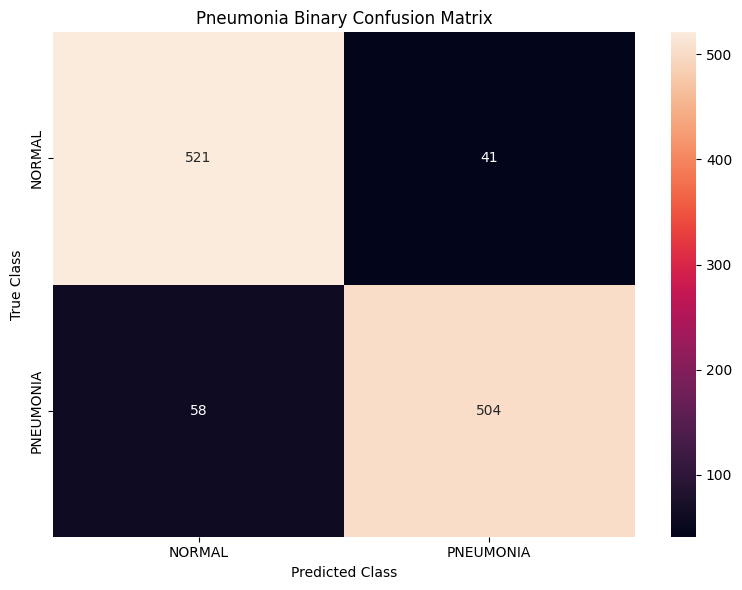

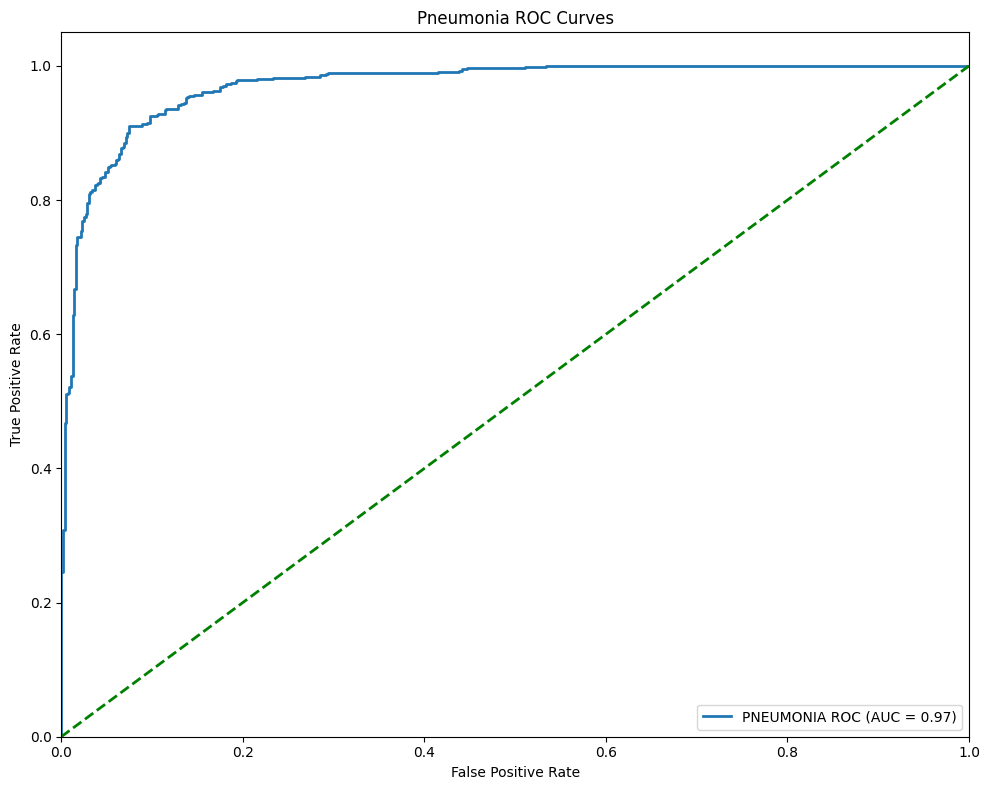

In [ ]:
# %% [markdown]
# # 8. Final Classification Evaluation & Visualizations
# %%
def evaluate_model(model, X_test, y_test, class_names):
    print("\nStarting Final Evaluation...")
    all_preds, all_probs, true_labels = [], [], []
    
    test_loader = DataPrefetcher(X_test, y_test, CONFIG['batch_size'], augment=False)
    
    while True:
        batch = test_loader.next()
        if batch is None: break
            
        X_batch, y_batch = batch
        logits = model.forward(X_batch)
        probs = cp.exp(logits - cp.max(logits, axis=-1, keepdims=True))
        probs /= cp.sum(probs, axis=-1, keepdims=True)
        
        all_probs.extend(cp.asnumpy(probs))
        all_preds.extend(cp.asnumpy(cp.argmax(logits, axis=-1)))
        true_labels.extend(cp.asnumpy(y_batch))
        force_free_vram()
        
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    true_labels = np.array(true_labels)
    
    print("\n--- Classification Report ---")
    print(classification_report(true_labels, all_preds, target_names=class_names, zero_division=0))
    
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(true_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='rocket', xticklabels=class_names, yticklabels=class_names)
    plt.title('Pneumonia Binary Confusion Matrix')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()
    plt.show()

    # --- THE FIX: Handle Binary vs Multi-Class ROC Curves safely ---
    plt.figure(figsize=(10, 8))
    
    if len(class_names) == 2:
        # Standard Binary ROC Curve (using probabilities of the positive class)
        fpr, tpr, _ = roc_curve(true_labels, all_probs[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[1]} ROC (AUC = {roc_auc:.2f})')
    else:
        # Multi-Class One-vs-Rest ROC Curves
        y_test_binarized = label_binarize(true_labels, classes=range(len(class_names)))
        for i, class_name in enumerate(class_names):
            if np.sum(y_test_binarized[:, i]) > 0:
                fpr, tpr, _ = roc_curve(y_test_binarized[:, i], all_probs[:, i])
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='green', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Pneumonia ROC Curves')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
    
# Execute Final Evaluation
evaluate_model(model, X_test, y_test, classes)

# 9. Visualizing Random Test Samples

Selecting 6 random samples from the test set...


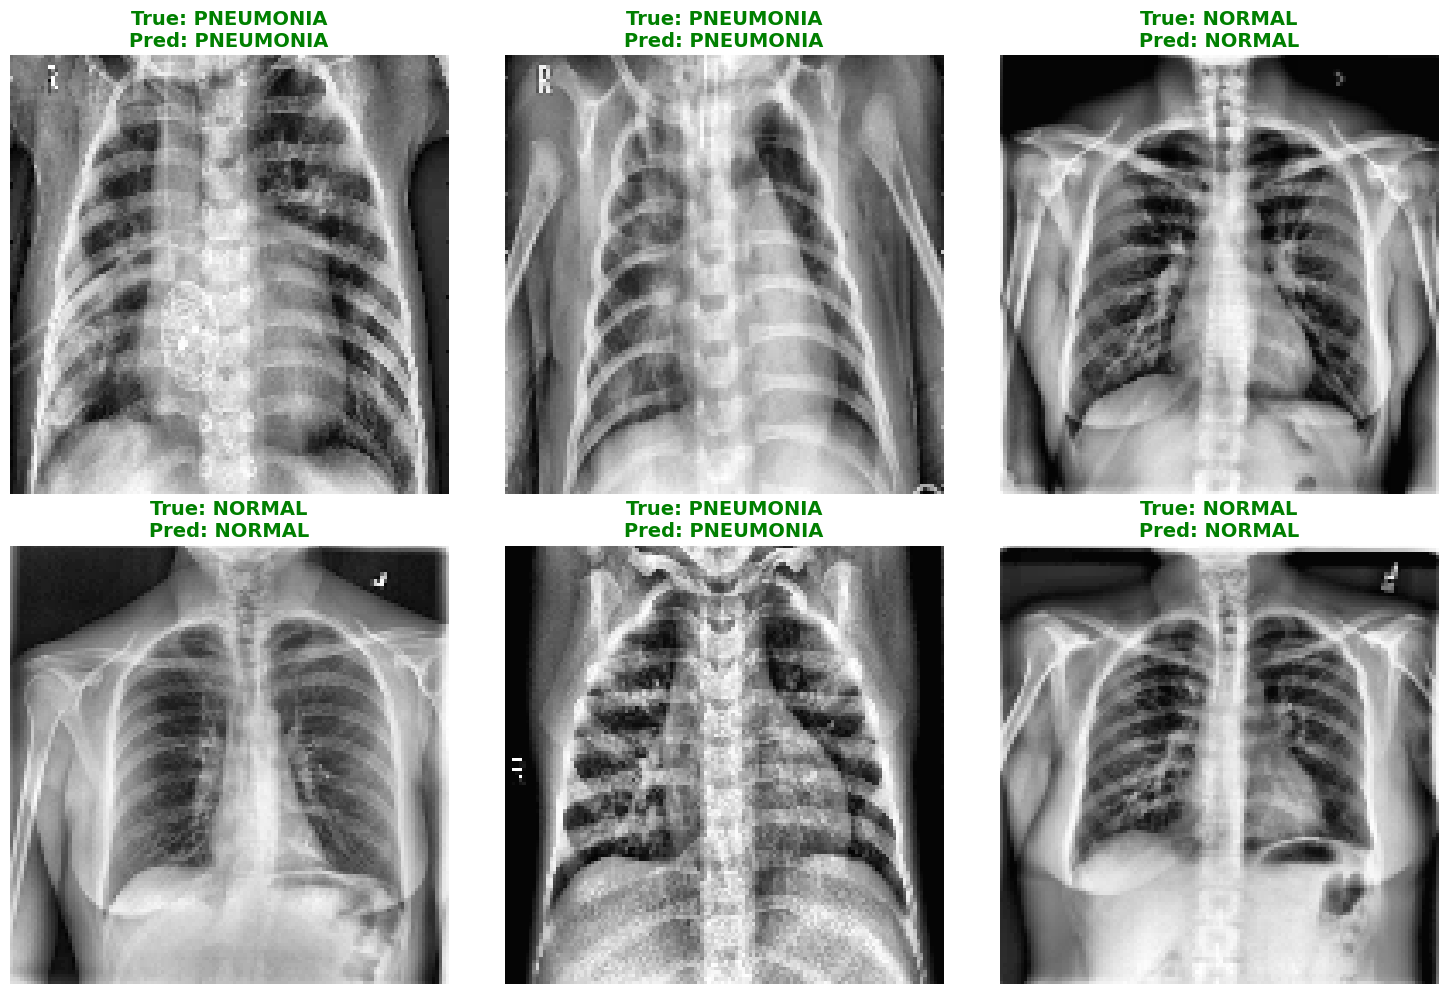

In [ ]:
def visualize_random_samples(model, X_test, y_test, class_names, num_samples=6):
    print(f"Selecting {num_samples} random samples from the test set...")
    indices = np.random.choice(len(X_test), num_samples, replace=False)
    X_samples = X_test[indices]
    y_samples = y_test[indices]
    X_gpu = cp.asarray(X_samples, dtype=cp.float32)
    logits = model.forward(X_gpu)
    preds = cp.argmax(logits, axis=-1)
    preds_cpu = cp.asnumpy(preds)
    
    cols = 3
    rows = math.ceil(num_samples / cols)
    plt.figure(figsize=(15, 5 * rows))
    
    for i in range(num_samples):
        plt.subplot(rows, cols, i + 1)
        img = X_samples[i].transpose(1, 2, 0)
        plt.imshow(img)
        plt.axis('off')
        
        true_label = class_names[y_samples[i]]
        pred_label = class_names[preds_cpu[i]]
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=14, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

visualize_random_samples(model, X_test, y_test, classes, num_samples=6)

# 10. Save Model & Configuration for Gradio Web App

In [ ]:
import pickle

def save_model_for_production(model, config, class_names, filename='pneumonia_pure_vit_model2.pkl'):
    print(f"Preparing to save model to {filename}...")
    export_package = {'model': model, 'config': config, 'classes': class_names}
    try:
        with open(filename, 'wb') as f:
            pickle.dump(export_package, f)
        file_size = os.path.getsize(filename) / (1024 * 1024)
        print(f"✅ Success! Model securely saved as '{filename}'.")
        print(f"📦 File Size: {file_size:.2f} MB")
    except Exception as e:
        print(f"❌ Error saving the model: {e}")

force_free_vram()
save_model_for_production(model, CONFIG, classes)

Preparing to save model to pneumonia_pure_vit_model.pkl...
✅ Success! Model securely saved as 'pneumonia_pure_vit_model.pkl'.
📦 File Size: 138.69 MB
